<a href="https://colab.research.google.com/github/Nour-682005/Deep-Learning-.Project/blob/main/deeep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 463kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.96MB/s]


In [4]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 7 * 7)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CNNModel()

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
epochs = 5
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
patience = 2
counter = 0


for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = 100 * correct / total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)
    print(
    f"Epoch [{epoch+1}/{epochs}] | "
    f"Train Loss: {epoch_loss:.4f}, "
    f"Train Acc: {epoch_acc:.2f}% | "
    f"Val Loss: {val_epoch_loss:.4f}, "
    f"Val Acc: {val_epoch_acc:.2f}%",
    flush=True
)

Epoch [1/5] | Train Loss: 0.1897, Train Acc: 94.22% | Val Loss: 0.0427, Val Acc: 98.61%
Epoch [2/5] | Train Loss: 0.0588, Train Acc: 98.21% | Val Loss: 0.0359, Val Acc: 98.69%
Epoch [3/5] | Train Loss: 0.0428, Train Acc: 98.76% | Val Loss: 0.0276, Val Acc: 99.01%
Epoch [4/5] | Train Loss: 0.0341, Train Acc: 98.95% | Val Loss: 0.0309, Val Acc: 99.04%
Epoch [5/5] | Train Loss: 0.0263, Train Acc: 99.15% | Val Loss: 0.0347, Val Acc: 98.89%


In [7]:
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()


        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
final_test_loss = test_loss / len(test_loader)
final_test_accuracy = 100 * correct / total

print("Test Loss:", final_test_loss)
print("Test Accuracy:", final_test_accuracy)

Test Loss: 0.0346796618547148
Test Accuracy: 98.89


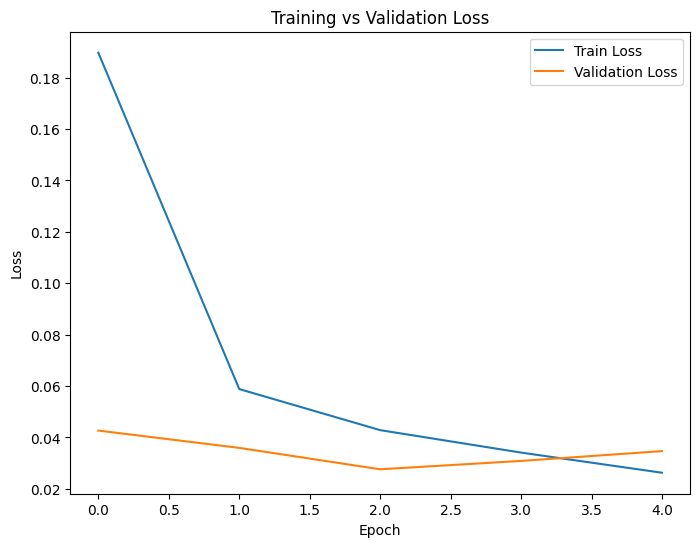

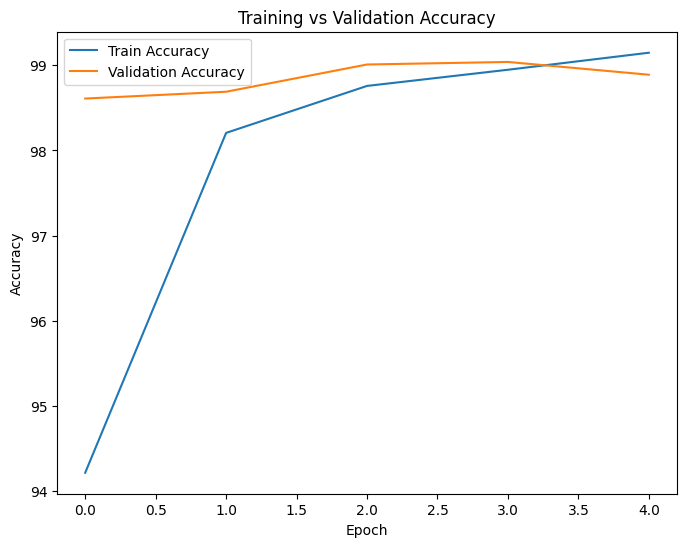

In [8]:
 #Loss Graph
plt.figure(figsize=(8,6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


# Accuracy Graph
plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


In [9]:
model2 = CNNModel()

criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.01)

epochs = 5

train_losses_2 = []
train_accuracies_2 = []
val_losses_2 = []
val_accuracies_2 = []

best_val_loss = float('inf')
patience = 2
counter = 0

for epoch in range(epochs):
    model2.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer2.zero_grad()

        outputs = model2(images)
        loss = criterion2(outputs, labels)

        loss.backward()
        optimizer2.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses_2.append(epoch_loss)
    train_accuracies_2.append(epoch_acc)

    model2.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model2(images)
            loss = criterion2(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = 100 * correct / total

    val_losses_2.append(val_epoch_loss)
    val_accuracies_2.append(val_epoch_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_loss:.4f}, "
        f"Train Acc: {epoch_acc:.2f}% | "
        f"Val Loss: {val_epoch_loss:.4f}, "
        f"Val Acc: {val_epoch_acc:.2f}%",
        flush=True
    )

model2.eval()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model2(images)
        loss = criterion2(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_test_loss_2 = test_loss / len(test_loader)
final_test_accuracy_2 = 100 * correct / total

print(f"Final Test Loss: {final_test_loss_2:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy_2:.2f}%")

Epoch [1/5] | Train Loss: 0.8663, Train Acc: 75.76% | Val Loss: 0.2421, Val Acc: 93.08%
Epoch [2/5] | Train Loss: 0.2318, Train Acc: 93.07% | Val Loss: 0.1444, Val Acc: 95.57%
Epoch [3/5] | Train Loss: 0.1492, Train Acc: 95.56% | Val Loss: 0.0921, Val Acc: 97.13%
Epoch [4/5] | Train Loss: 0.1130, Train Acc: 96.67% | Val Loss: 0.0745, Val Acc: 97.71%
Epoch [5/5] | Train Loss: 0.0955, Train Acc: 97.14% | Val Loss: 0.0633, Val Acc: 98.14%
Final Test Loss: 0.0633
Final Test Accuracy: 98.14%


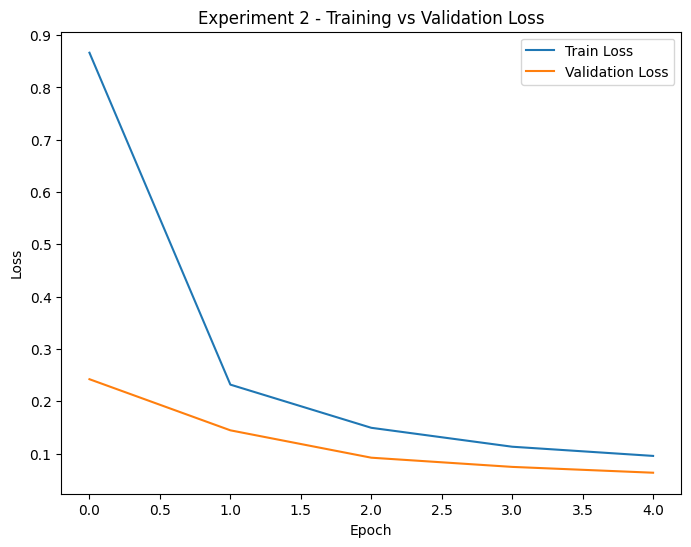

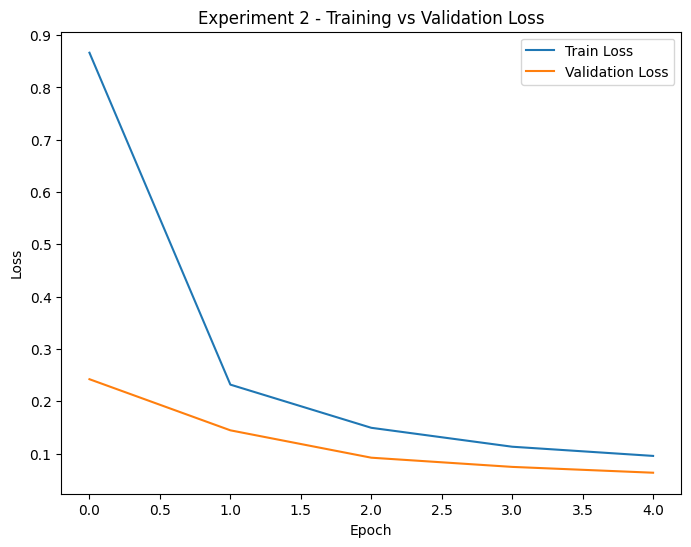

In [10]:
# loss
plt.figure(figsize=(8,6))
plt.plot(train_losses_2, label='Train Loss')
plt.plot(val_losses_2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 2 - Training vs Validation Loss')
plt.legend()
plt.show()


#Accuracy
plt.figure(figsize=(8,6))
plt.plot(train_losses_2, label='Train Loss')
plt.plot(val_losses_2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 2 - Training vs Validation Loss')
plt.legend()
plt.show()

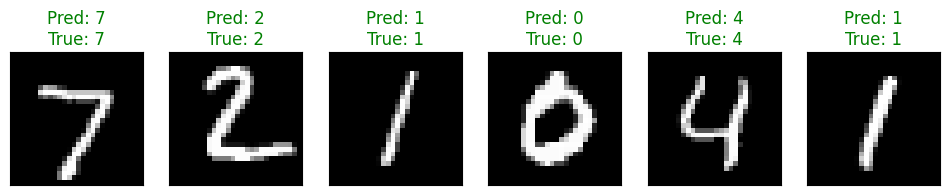

In [11]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(12, 4))
for idx in range(6):
    ax = fig.add_subplot(1, 6, idx+1, xticks=[], yticks=[])

    img = images[idx] / 2 + 0.5
    plt.imshow(img.squeeze(), cmap='gray')

    ax.set_title(f"Pred: {predicted[idx].item()}\nTrue: {labels[idx].item()}",
                 color=("green" if predicted[idx]==labels[idx] else "red"))

plt.show()